In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import (
    resnet50, vit_b_16,
    ResNet50_Weights, ViT_B_16_Weights
)
from PIL import Image
from huggingface_hub import hf_hub_download
from IPython.display import display

In [19]:
class HybridModel(nn.Module):
    def __init__(self, num_classes=4):
        super(HybridModel, self).__init__()
        self.resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        resnet_in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()

        self.vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        vit_in_features = self.vit.heads.head.in_features
        self.vit.heads = nn.Identity()

        self.fc = nn.Sequential(
            nn.Linear(resnet_in_features + vit_in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x_resnet, x_vit = x
        local_features = self.resnet(x_resnet)
        global_features = self.vit(x_vit)
        combined_features = torch.cat((local_features, global_features), dim=1)
        return self.fc(combined_features)

In [20]:
def load_model():
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model_path = hf_hub_download(
        repo_id="kelvinandreas/Green_Arabica_Coffee_Bean_Classification_R50-V",
        filename="best_model.pth"
    )

    model = HybridModel(num_classes=4)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    return model, device

def preprocess_image(image_path, device):
    image = Image.open(image_path).convert("RGB")

    preprocess_resnet = ResNet50_Weights.IMAGENET1K_V1.transforms()
    preprocess_vit = ViT_B_16_Weights.IMAGENET1K_V1.transforms()

    x_resnet = preprocess_resnet(image).unsqueeze(0).to(device)
    x_vit = preprocess_vit(image).unsqueeze(0).to(device)

    return x_resnet, x_vit

def predict(image_path):
    CLASS_LABELS = ['Defect', 'Longberry', 'Peaberry', 'Premium']

    model, device = load_model()
    x_resnet, x_vit = preprocess_image(image_path, device)

    with torch.no_grad():
        logits = model((x_resnet, x_vit))

    probs = F.softmax(logits, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred_idx].item()

    return {
        "prediction": CLASS_LABELS[pred_idx],
        "confidence_percent": round(confidence * 100, 2)
    }

In [21]:
image_path = "/content/drive/MyDrive/SHARE/SKRIPSI/sample_image.png"

result = predict(image_path)

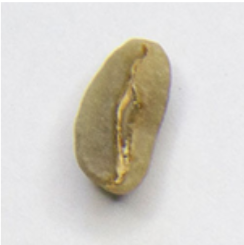


💡 PREDICTION RESULT
🫘 Class      : Longberry
📊 Confidence : 95.7%



In [23]:
img = Image.open(image_path)
display(img)

print("\n" + "="*40)
print("💡 PREDICTION RESULT")
print("="*40)
print(f"🫘 Class      : {result['prediction']}")
print(f"📊 Confidence : {result['confidence_percent']}%")
print("="*40 + "\n")